### 105. Construct Binary Tree from Preorder and Inorder Traversal
#### Given two integer arrays preorder and inorder where preorder is the preorder traversal of a binary tree and inorder is the inorder traversal of the same tree, construct and return the binary tree.
###### 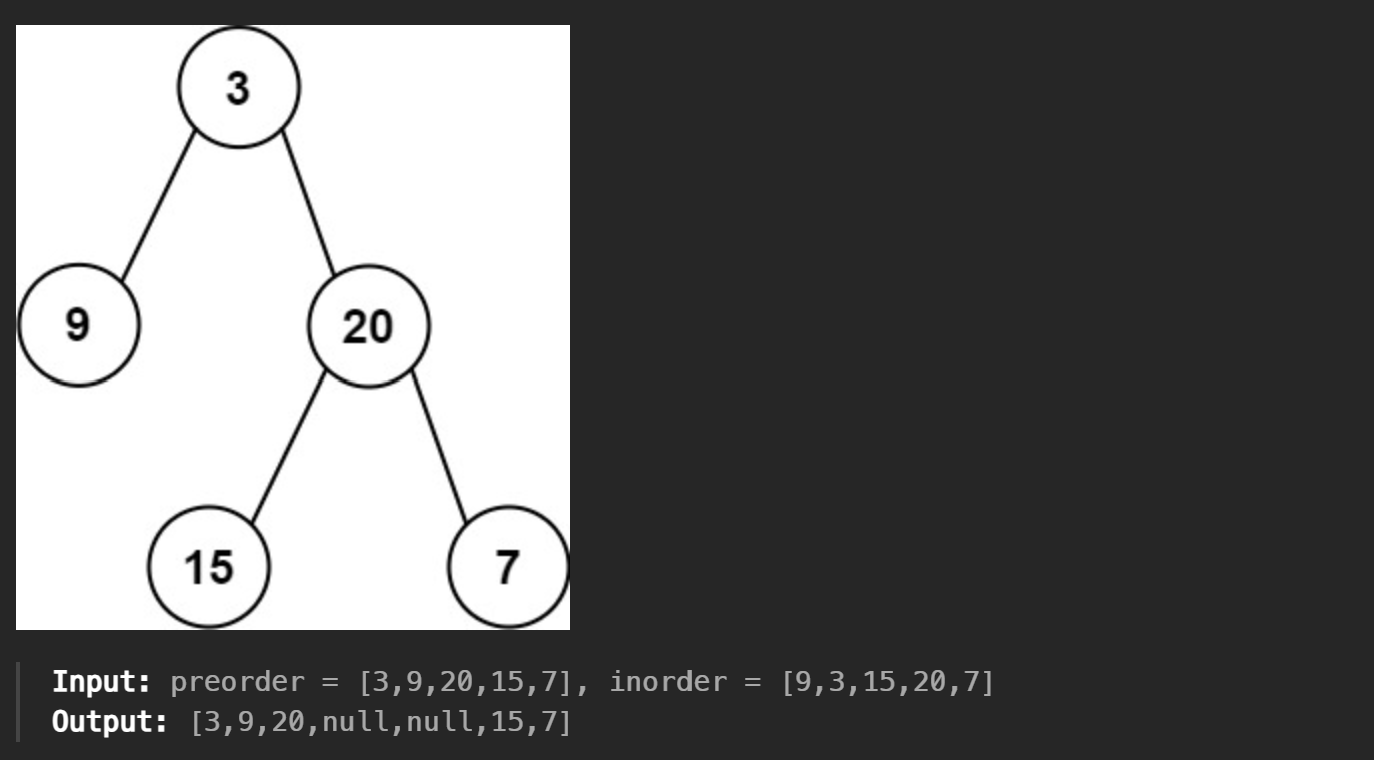

### Java Solution
```java
class Solution {
    public TreeNode buildTree(int[] preorder, int[] inorder) {
        Map<Integer,Integer> inOrderIndexMap = new HashMap<>();
        for(int i=0;i<inorder.length;i++){
            inOrderIndexMap.put(inorder[i],i);
        }

        return splitTree(preorder,inOrderIndexMap,0,0,inorder.length-1);
    }

    private TreeNode splitTree(int[] preorder,Map<Integer,Integer> inOrderIndexMap,int rootIndex,int left,int right){
        TreeNode root = new TreeNode(preorder[rootIndex]);
        int mid = inOrderIndexMap.get(preorder[rootIndex]);
        if(mid>left){
            root.left = splitTree(preorder,inOrderIndexMap,rootIndex+1,left,mid-1);
        }
        if(mid<right){
            root.right = splitTree(preorder,inOrderIndexMap,rootIndex+mid-left+1,mid+1,right);
        }
        return root;
    }
}
```

### Cpp Solution
```cpp
class Solution {
private:

    unordered_map<int, int> inorderMap;
    
    TreeNode* build(vector<int>& preorder, int preStart, int inStart, int inEnd) {
        
        if (inStart > inEnd || preStart >= preorder.size()) {
            return nullptr;
        }
        
        
        int rootVal = preorder[preStart];
        TreeNode* root = new TreeNode(rootVal);
        
     
        int rootIndex = inorderMap[rootVal];
        
        int leftSize = rootIndex - inStart;
        
        
        root->left = build(preorder, preStart + 1, inStart, rootIndex - 1);
        root->right = build(preorder, preStart + 1 + leftSize, rootIndex + 1, inEnd);
        
        return root;
    }
    
public:
    TreeNode* buildTree(vector<int>& preorder, vector<int>& inorder) {
       
        for (int i = 0; i < inorder.size(); i++) {
            inorderMap[inorder[i]] = i;
        }
        
      
        return build(preorder, 0, 0, inorder.size() - 1);
    }
};
```

### Python Solution

In [ ]:
class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        inorder_map = {val: idx for idx, val in enumerate(inorder)}
        
        def build(pre_start, in_start, in_end):
            if in_start > in_end:
                return None
            
      
            root_val = preorder[pre_start]
            root = TreeNode(root_val)
            
            root_index = inorder_map[root_val]
            
            
            left_size = root_index - in_start
            
          
            root.left = build(pre_start + 1, in_start, root_index - 1)
            root.right = build(pre_start + 1 + left_size, root_index + 1, in_end)
            
            return root
            
      
        return build(0, 0, len(inorder) - 1)